In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df = pd.read_csv("KADIRS_Tax_Compliance_2000_Rows.csv")

In [3]:
# Create a backup
df_clean = df.copy()

In [4]:
df_clean.shape

(2000, 29)

In [5]:
missing = pd.DataFrame({
    'Missing Values': df_clean.isnull().sum(),
    'Percentage (%)': (df_clean.isnull().sum() / len(df_clean)) * 100
})

missing.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
filing_date,649,32.45
record_id,0,0.00
amount_assessed,0,0.00
revenue_office,0,0.00
compliance_score,0,0.00
risk_level,0,0.00
annual_turnover,0,0.00
penalty,0,0.00
audit_result,0,0.00
audit_status,0,0.00


In [6]:
df_clean.duplicated().sum()

np.int64(0)

In [7]:
df_clean.dtypes

record_id               int64
taxpayer_id             int64
tin                    object
business_name          object
owner_name             object
taxpayer_type          object
business_sector        object
lga                    object
registration_date      object
tax_year                int64
tax_month              object
tax_type               object
filing_due_date        object
filing_date            object
filing_status          object
amount_assessed         int64
amount_paid             int64
outstanding_balance     int64
payment_status         object
payment_method         object
payment_date           object
audit_status           object
audit_result           object
penalty                 int64
annual_turnover         int64
risk_level             object
compliance_score        int64
revenue_office         object
notification_sent      object
dtype: object

In [8]:
date_columns = [
    'registration_date',
    'filing_due_date',
    'filing_date',
    'payment_date'
]

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

In [9]:
df_clean.dtypes

record_id                       int64
taxpayer_id                     int64
tin                            object
business_name                  object
owner_name                     object
taxpayer_type                  object
business_sector                object
lga                            object
registration_date      datetime64[ns]
tax_year                        int64
tax_month                      object
tax_type                       object
filing_due_date        datetime64[ns]
filing_date            datetime64[ns]
filing_status                  object
amount_assessed                 int64
amount_paid                     int64
outstanding_balance             int64
payment_status                 object
payment_method                 object
payment_date           datetime64[ns]
audit_status                   object
audit_result                   object
penalty                         int64
annual_turnover                 int64
risk_level                     object
compliance_s

In [10]:
text_columns = [
    'taxpayer_type',
    'business_sector',
    'lga',
    'tax_type',
    'filing_status',
    'payment_status',
    'payment_method',
    'audit_status',
    'risk_level',
    'revenue_office'
]

for col in text_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

In [11]:
df_clean['lga'].unique()

array(['Igabi', 'Kaduna North', 'Makarfi', 'Jaba', 'Chikun', 'Sabon Gari',
       'Lere', 'Soba', 'Giwa', 'Zangon Kataf', 'Kagarko', 'Kaduna South',
       'Kachia', 'Kudan', 'Kajuru', 'Kauru', 'Ikara', 'Sanga',
       'Birnin Gwari', 'Kubau', "Jema'A", 'Kaura', 'Zaria'], dtype=object)

In [12]:
df_clean['taxpayer_type'].unique()

array(['Individual', 'Sme', 'Corporate'], dtype=object)

In [13]:
df_clean['payment_status'].unique()

array(['Paid', 'Partial'], dtype=object)

In [14]:
df_clean['filing_status'].unique()

array(['Filed', 'Not Filed', 'Late'], dtype=object)

In [15]:
numeric_columns = df_clean.select_dtypes(include=np.number)

numeric_columns.describe()

,record_id,taxpayer_id,tax_year,amount_assessed,amount_paid,outstanding_balance,penalty,annual_turnover,compliance_score
count,2000.000000,2000.000000,2000.0,2.000000e+03,2.000000e+03,2.000000e+03,2000.000000,2.000000e+03,2000.000000
mean,1000.500000,100344.825000,2025.0,2.590214e+06,1.961347e+06,6.288673e+05,99467.005000,2.526930e+08,59.616500
std,577.494589,200.586328,0.0,1.440362e+06,1.523135e+06,1.121835e+06,58012.701994,1.427763e+08,23.496733
min,1.000000,100001.000000,2025.0,5.154600e+04,3.590000e+02,0.000000e+00,15.000000,2.452751e+06,20.000000
25%,500.750000,100167.750000,2025.0,1.348322e+06,5.783630e+05,0.000000e+00,48284.750000,1.288968e+08,39.000000
50%,1000.500000,100339.500000,2025.0,2.652268e+06,1.605515e+06,0.000000e+00,98355.000000,2.488678e+08,59.000000
75%,1500.250000,100520.000000,2025.0,3.825827e+06,3.269239e+06,9.156542e+05,151123.250000,3.750891e+08,80.000000
max,2000.000000,100700.000000,2025.0,4.998164e+06,4.996304e+06,4.756206e+06,199926.000000,4.997221e+08,100.000000


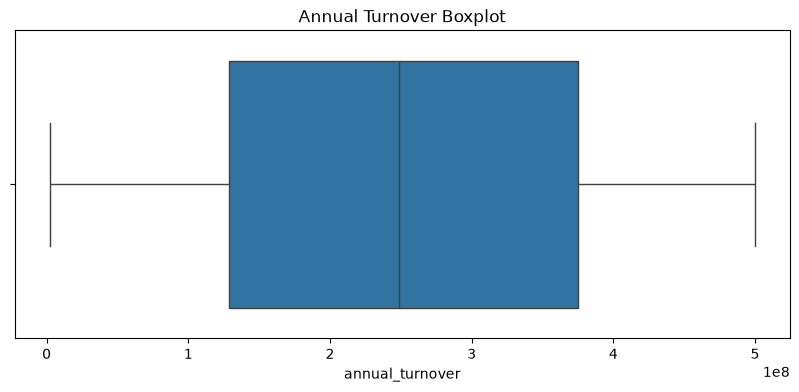

In [16]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_clean['annual_turnover'])

plt.title("Annual Turnover Boxplot")
plt.show()

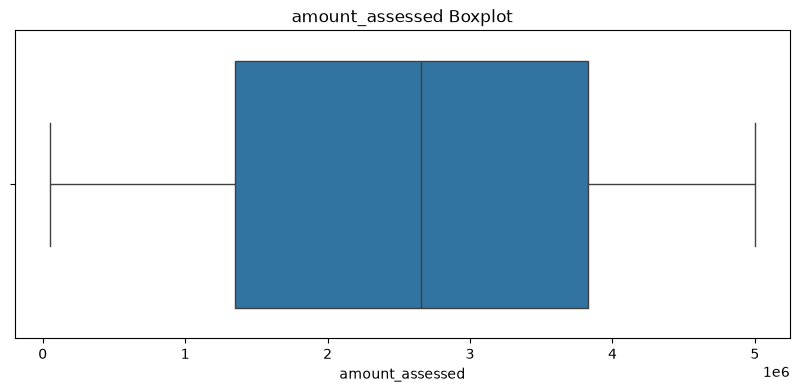

In [17]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_clean['amount_assessed'])

plt.title("amount_assessed Boxplot")
plt.show()

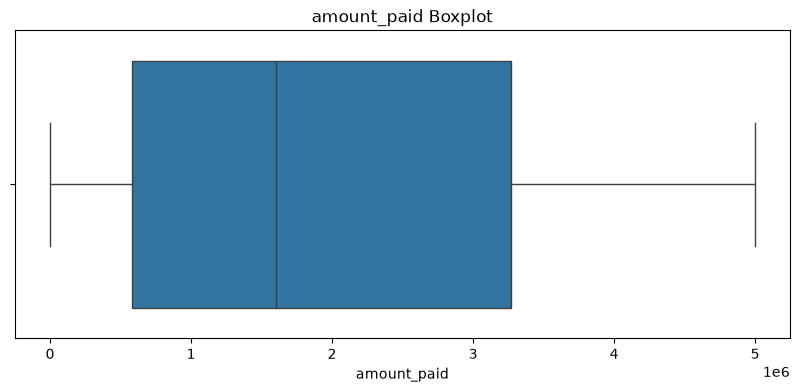

In [18]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_clean['amount_paid'])

plt.title("amount_paid Boxplot")
plt.show()

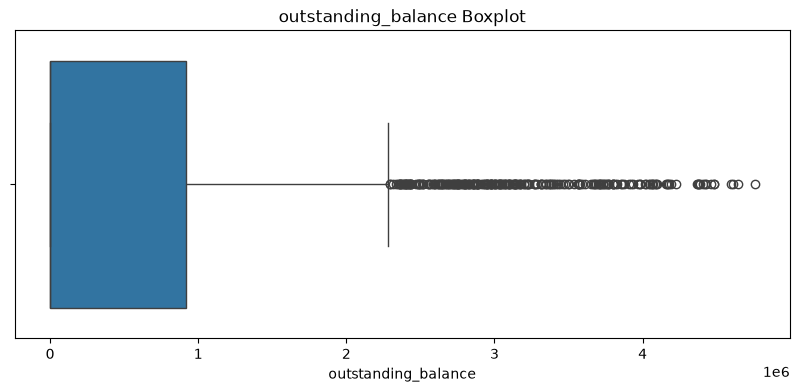

In [19]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_clean['outstanding_balance'])

plt.title("outstanding_balance Boxplot")
plt.show()

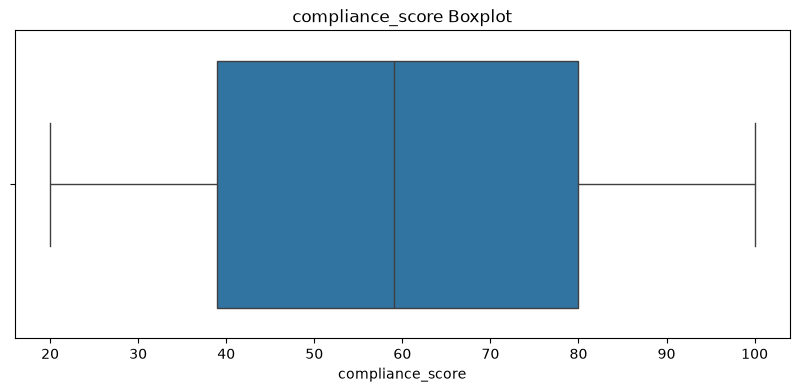

In [20]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_clean['compliance_score'])

plt.title("compliance_score Boxplot")
plt.show()

In [21]:
df_clean[df_clean['amount_paid'] < 0]

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,payment_method,payment_date,audit_status,audit_result,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent


In [22]:
df_clean[df_clean['amount_assessed'] < 0]

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,payment_method,payment_date,audit_status,audit_result,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent


In [23]:
df_clean[df_clean['annual_turnover'] < 0]

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,payment_method,payment_date,audit_status,audit_result,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent


In [24]:
df_clean['registration_year'] = df_clean['registration_date'].dt.year

In [25]:
df_clean['registration_month'] = df_clean['registration_date'].dt.month_name()

In [26]:
df_clean['filing_month'] = df_clean['filing_due_date'].dt.month_name()

In [27]:
df_clean['payment_month'] = df_clean['payment_date'].dt.month_name()

In [28]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            2000 non-null   int64         
 1   taxpayer_id          2000 non-null   int64         
 2   tin                  2000 non-null   object        
 3   business_name        2000 non-null   object        
 4   owner_name           2000 non-null   object        
 5   taxpayer_type        2000 non-null   object        
 6   business_sector      2000 non-null   object        
 7   lga                  2000 non-null   object        
 8   registration_date    2000 non-null   datetime64[ns]
 9   tax_year             2000 non-null   int64         
 10  tax_month            2000 non-null   object        
 11  tax_type             2000 non-null   object        
 12  filing_due_date      2000 non-null   datetime64[ns]
 13  filing_date          525 non-null

In [29]:
df_clean.describe(include='all')

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent,registration_year,registration_month,filing_month,payment_month
count,2000.000000,2000.000000,2000,2000,2000,2000,2000,2000,2000,2000.0,...,2000.000000,2.000000e+03,2000,2000.000000,2000,2000,2000.000000,2000,2000,2000
unique,NaN,NaN,2000,1918,1968,3,5,23,NaN,NaN,...,NaN,NaN,3,NaN,3,2,NaN,12,12,12
top,NaN,NaN,KAD-TIN-202500000,Williams Inc,Michael Castillo,Corporate,Healthcare,Igabi,NaN,NaN,...,NaN,NaN,Medium,NaN,Zaria,Yes,NaN,January,July,July
freq,NaN,NaN,1,5,4,698,414,102,NaN,NaN,...,NaN,NaN,681,NaN,685,1039,NaN,271,185,192
mean,1000.500000,100344.825000,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-03 03:18:43.200000256,2025.0,...,99467.005000,2.526930e+08,NaN,59.616500,NaN,NaN,2024.268000,NaN,NaN,NaN
min,1.000000,100001.000000,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,2025.0,...,15.000000,2.452751e+06,NaN,20.000000,NaN,NaN,2024.000000,NaN,NaN,NaN
25%,500.750000,100167.750000,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-29 18:00:00,2025.0,...,48284.750000,1.288968e+08,NaN,39.000000,NaN,NaN,2024.000000,NaN,NaN,NaN
50%,1000.500000,100339.500000,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-01 00:00:00,2025.0,...,98355.000000,2.488678e+08,NaN,59.000000,NaN,NaN,2024.000000,NaN,NaN,NaN
75%,1500.250000,100520.000000,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-08 00:00:00,2025.0,...,151123.250000,3.750891e+08,NaN,80.000000,NaN,NaN,2025.000000,NaN,NaN,NaN
max,2000.000000,100700.000000,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-15 00:00:00,2025.0,...,199926.000000,4.997221e+08,NaN,100.000000,NaN,NaN,2025.000000,NaN,NaN,NaN


In [30]:
df_clean.head()

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent,registration_year,registration_month,filing_month,payment_month
0,1,100251,KAD-TIN-202500000,Robinson and Sons,Kayla May,Individual,Ict,Igabi,2024-11-23,2025,...,57314,126908867,High,97,Kaduna North,Yes,2024,November,February,February
1,2,100226,KAD-TIN-202500001,"Conrad, Colon and Wilson",Haley Lewis,Sme,Healthcare,Kaduna North,2025-01-01,2025,...,56443,411897789,Medium,33,Kaduna North,No,2025,January,December,January
2,3,100045,KAD-TIN-202500002,Davidson LLC,Barbara Buckley,Corporate,Manufacturing,Makarfi,2024-02-19,2025,...,18233,26601779,High,49,Kaduna South,Yes,2024,February,September,October
3,4,100285,KAD-TIN-202500003,Burch-Waller,Jon Smith,Sme,Agriculture,Jaba,2025-03-13,2025,...,191136,133431865,Low,79,Kaduna South,No,2025,March,August,August
4,5,100333,KAD-TIN-202500004,"Alvarez, Rodriguez and Bennett",Amanda Gonzalez,Individual,Ict,Chikun,2025-04-18,2025,...,188196,170941402,Low,83,Kaduna South,No,2025,April,April,April


In [31]:
df_clean.to_csv("cleaned_KADIRS_Tax_Compliance.csv", index=False)

In [32]:
The dataset was cleaned by removing duplicate records, converting date columns to the appropriate datetime format, standardizing categorical values, validating numerical fields, and creating additional date-based features for analysis. The cleaned dataset was then saved for use in the exploratory data analysis and dashboard development stages.

SyntaxError: invalid syntax (3513572591.py, line 1)

In [33]:
invalid_payment = df[df["amount_paid"] > df["amount_assessed"]]

print(invalid_payment.shape)

(0, 29)


In [34]:
df.loc[df["amount_paid"] > df["amount_assessed"],
       "amount_paid"] = df["amount_assessed"]

In [35]:
incorrect_balance = df[
    df["outstanding_balance"] !=
    (df["amount_assessed"] - df["amount_paid"])
]

incorrect_balance.head()

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,payment_method,payment_date,audit_status,audit_result,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent


In [36]:
df["outstanding_balance"] = (
    df["amount_assessed"] -
    df["amount_paid"]
)

In [37]:
invalid_payment_date = df[
    (df["payment_status"] == "Unpaid") &
    (df["payment_date"].notna())
]

invalid_payment_date

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,payment_method,payment_date,audit_status,audit_result,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent


In [38]:
df[df["penalty"] < 0]

,record_id,taxpayer_id,tin,business_name,owner_name,taxpayer_type,business_sector,lga,registration_date,tax_year,...,payment_method,payment_date,audit_status,audit_result,penalty,annual_turnover,risk_level,compliance_score,revenue_office,notification_sent
